# CNC 밀링 머신 공구 마모 탐지 — 실습 (클린 버전)

> **세션 1 · 제조 데이터 심층 분석**  |  데이터: *CNC Mill Tool Wear* (University of Michigan SMART Lab)

---

## 0. 이 노트북의 목표

> **"센서 데이터만 보고, 이 공구가 닳았는지(worn) 멀쩡한지(unworn) 알 수 있을까?"**

공구가 마모된 채 가공하면 제품 불량·가공 실패·설비 손상으로 이어집니다. 그래서 공구 마모 탐지는
**예지 보전(Predictive Maintenance)** 의 출발점입니다.

이 버전은 **처음부터 데이터 누수 없이, 올바른 평가 방법(실험 단위 분할)** 으로 진행합니다.
EDA → 특징공학 → 올바른 분할(GroupKFold) → 모델링·평가 → **Claude Code 실습** 순서입니다.

> **강의 진행 가이드 (약 60분 + 실습)**
> - 1. 도메인 이해 (8분) · 2. 로드·전처리 (7분) · 3. EDA (12분)
> - 4. 특징공학: 윈도우 + Wavelet (8분)
> - 5. 올바른 분할과 모델링 (15분)
> - 6. Claude Code 실습 (가변) · 7. 정리 (2분)

### 산출물 스펙 매핑
| 스펙 항목 | 다루는 섹션 |
|---|---|
| 1-1 핵심 알고리즘 | 4(Wavelet 특징) · 5(LightGBM·SMOTE) |
| 1-2 EDA(데이터 특성) | 3. EDA |
| 1-3 왜 이렇게 푸는가 | 5. 실험 단위 분할·유효표본 |
| 1-4 코드별 설명 | 전 코드 셀 하단 [코드 설명]/[해석] |

---
## 1. 도메인 이해 — CNC 밀링과 공구 마모

### 1.1 CNC 밀링 머신
컴퓨터 프로그램(G-code)대로 회전 절삭 공구를 움직여 소재를 깎는 기계입니다.
- X / Y / Z 축: 직선 이동 / **S 축(주축)**: 공구를 회전시키는 축(절삭 에너지가 나오는 곳)

### 1.2 공구 마모가 왜 중요한가
절삭날이 닳으면 절삭 저항·마찰이 커집니다. 같은 명령에도 추종 오차가 커지고, 전류·전력 소비가 늘죠.
마모 시점을 놓치면 불량 양산 + 공구 파손 → 그래서 마모 탐지가 예지 보전의 첫 단추입니다.

### 1.3 데이터셋: UMich SMART Lab "CNC Mill Tool Wear"
미시간대 SMART 연구실의 **벤치마크 데이터셋**입니다. 실제 공장 데이터가 아니라, "센서로 공구 마모를
탐지하는 방법"을 안전·저렴하게 개발·검증하려고 **통제된 실험실에서 수집한** 데이터예요.

- **왜 왁스(양초 재질) 블록?** 같은 실험을 18번 반복하려면 금속은 비싸고 느립니다. 왁스는 빠르고 안전하게
  반복할 수 있고, 목적이 "센서 신호 수집"이라 소재 자체는 중요하지 않습니다.
- **'S'자를 깎았다?** 공구가 지나가는 가공 경로(모양)가 S자입니다(연구실 SMART의 S). 직선·곡선·방향전환이
  섞이도록 설계된 테스트 형상이에요.
- **구성**: 이송속도·고정압력·공구상태를 조합해 18회, 100ms(10Hz)로 48개 센서값 기록.
  - experiment_01~18.csv: 48컬럼 시계열 / train.csv: 실험 단위 메타 + 라벨(tool_condition 등)

> **참고 — 이 데이터는 '진동(가속도계) 신호'가 아니다**
> 48컬럼은 가속도계 고주파 진동이 아니라 CNC 컨트롤러가 10Hz로 기록한 제어 텔레메트리입니다.
> 나이퀴스트가 5Hz라 **채터링(수백 Hz~kHz)** 같은 진동 시그니처는 애초에 담기지 않습니다.
> (채터링을 직접 다루는 실습은 6절에서 '합성 신호'로 따로 해봅니다.)

---
## 2. 환경 설정 & 데이터 로드  ` [1-4 코드별 설명]`

> **실행 환경** — Colab / 로컬 모두 지원. 첫 셀이 환경을 감지해 (Colab이면) 패키지·한글폰트를 설치합니다.

In [1]:
# --- [환경 설정] Colab 자동 감지 ---
import sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run("pip install -q PyWavelets imbalanced-learn lightgbm", shell=True)
    subprocess.run("apt-get -qq -y install fonts-nanum > /dev/null 2>&1", shell=True)
    import matplotlib.font_manager as fm
    try: fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    except Exception: pass
    print("Colab 환경 설정 완료")
else:
    print("로컬 환경")

로컬 환경


In [2]:
import os, glob, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pywt
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid"); plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)

import matplotlib.font_manager as _fm
_avail = {f.name for f in _fm.fontManager.ttflist}
for _f in ["AppleGothic", "NanumGothic", "Malgun Gothic"]:
    if _f in _avail:
        plt.rcParams["font.family"] = _f; print("한글 폰트:", _f); break
else:
    print("한글 폰트 미발견")

한글 폰트: AppleGothic


### 데이터 준비
로컬은 `data/` 폴더에 CSV가 있으면 됩니다. Colab이면 `data.zip`을 업로드한 뒤 한 줄로 풉니다.

```python
!unzip data.zip -d data/
```

In [3]:
def find_data_dir():
    for base in ["data", ".", "/kaggle/input/tool-wear-detection-in-cnc-mill"]:
        hits = glob.glob(os.path.join(base, "**", "train.csv"), recursive=True)
        if hits: return os.path.dirname(hits[0])
    raise FileNotFoundError("train.csv 없음 → data/ 폴더에 데이터셋을 넣어주세요.")
DATA_DIR = find_data_dir(); print("데이터 경로:", DATA_DIR)
exp_meta = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
exp_meta["passed_visual_inspection"] = exp_meta["passed_visual_inspection"].fillna("no")
exp_meta[["No","feedrate","clamp_pressure","tool_condition"]]

데이터 경로: data


,No,feedrate,clamp_pressure,tool_condition
0,1,6,4.0,unworn
1,2,20,4.0,unworn
2,3,6,3.0,unworn
3,4,6,2.5,unworn
4,5,20,3.0,unworn
5,6,6,4.0,worn
6,7,20,4.0,worn
7,8,20,4.0,worn
8,9,15,4.0,worn
9,10,12,4.0,worn


### 18개 파일 통합 + 실험번호 남기기
센서 측정값 18개 파일에 각 실험의 정답(tool_condition)을 붙여 한 표로 만듭니다.
이때 **실험 번호(exp_num)** 를 꼭 남깁니다 — 5절에서 "같은 실험은 한쪽에만" 강제할 때 그룹 키로 씁니다.

> ⚠️ machining_finalized·passed_visual_inspection은 **가공이 끝난 뒤** 알 수 있는 값이라, 입력 피처로 쓰면
> "정답 컨닝"(타깃 누수)이 됩니다. 그래서 처음부터 피처에 넣지 않습니다.

In [4]:
frames = []
for i in range(1, 19):
    ts = pd.read_csv(os.path.join(DATA_DIR, f"experiment_{i:02d}.csv"))
    row = exp_meta[exp_meta["No"] == i].iloc[0]
    ts["exp_num"] = i
    ts["target"] = int(row["tool_condition"] == "worn")   # worn=1, unworn=0
    frames.append(ts)
df = pd.concat(frames, ignore_index=True)
df["Machining_Process"] = df["Machining_Process"].replace({"Starting": "Prep", "end": "End"})
print("통합:", df.shape)

통합: (25286, 50)


### 절삭 구간만 사용 — 왜?
무딘 칼과 잘 드는 칼은 **도마에 가만히 놓여 있을 땐 똑같고, 실제로 썰 때만** 차이가 납니다.
공구 마모도 **실제 깎는 순간**에만 신호로 드러나죠(마모는 절삭 저항·전류에 영향을 주니까요).

CNC는 깎기만 하지 않습니다. `Machining_Process`가 `Layer …`면 실제 절삭, `Repositioning/Prep`면 허공 이동입니다.
비절삭 구간은 worn/unworn이 거의 똑같아 진짜 신호를 희석시키므로, **절삭 구간만** 남깁니다.

In [5]:
cut = df[df["Machining_Process"].str.startswith("Layer")].copy()
print(f"절삭 구간 {len(cut):,}행 / 전체 {len(df):,}행  ({len(cut)/len(df)*100:.0f}%)")

절삭 구간 17,520행 / 전체 25,286행  (69%)


---
## 3. EDA — 데이터 특성 파악  ` [1-2 데이터 특성]`

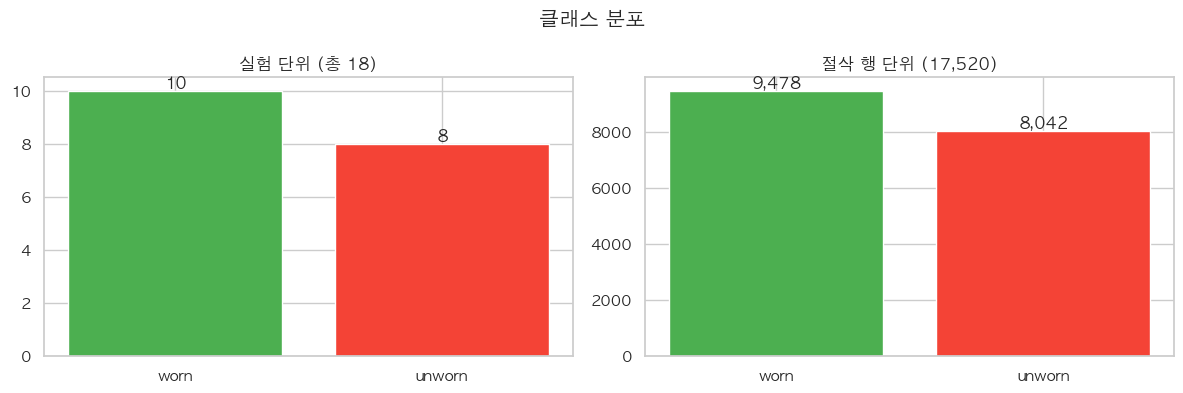

In [6]:
# --- 클래스 분포 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
e = exp_meta["tool_condition"].value_counts()
ax[0].bar(e.index, e.values, color=["#4CAF50","#F44336"]); ax[0].set_title(f"실험 단위 (총 {len(exp_meta)})")
for i,v in enumerate(e.values): ax[0].text(i,v,str(v),ha="center",va="bottom")
r = cut["target"].map({0:"unworn",1:"worn"}).value_counts()
ax[1].bar(r.index, r.values, color=["#4CAF50","#F44336"]); ax[1].set_title(f"절삭 행 단위 ({len(cut):,})")
for i,v in enumerate(r.values): ax[1].text(i,v,f"{v:,}",ha="center",va="bottom")
plt.suptitle("클래스 분포"); plt.tight_layout(); plt.show()

**[관찰]** tool_condition은 worn 10 : unworn 8 로 **거의 균형**입니다(심한 불균형 아님).

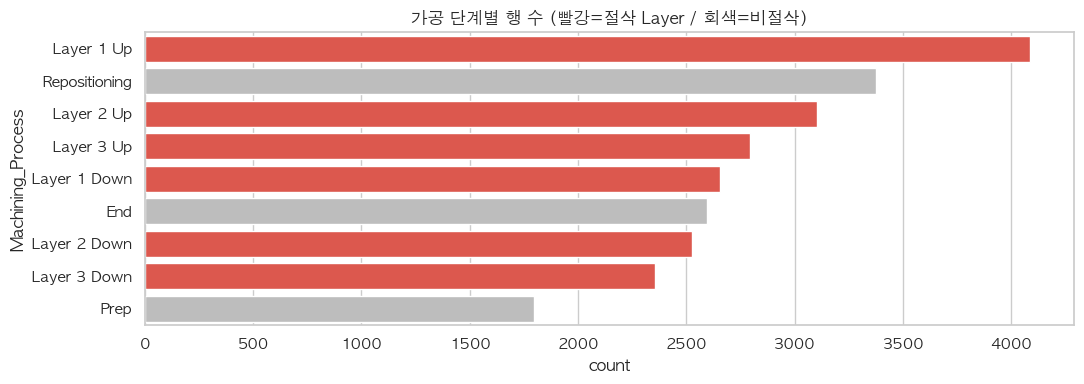

In [7]:
# --- 가공 단계(Machining_Process) 분포 — 절삭 구간 필터의 근거 ---
plt.figure(figsize=(11, 4))
vc = df["Machining_Process"].value_counts()
colors = ["#F44336" if s.startswith("Layer") else "#BDBDBD" for s in vc.index]
sns.barplot(x=vc.values, y=vc.index, palette=colors)
plt.title("가공 단계별 행 수 (빨강=절삭 Layer / 회색=비절삭)"); plt.xlabel("count"); plt.tight_layout(); plt.show()

**[해석·전처리 인사이트]** 빨강(Layer*)이 실제 절삭 구간, 회색(Prep·Repositioning 등)이 공구가 허공을 도는 비절삭 구간입니다.
비절삭이 약 30%나 됩니다. **공구 마모는 절삭 중에만 신호로 드러나므로**, 2절에서 절삭 구간만 남긴 것이 타당함을
여기서 눈으로 확인합니다. (전처리는 '왜 이 행을 남기고 버리는가'를 데이터로 정당화하는 과정입니다.)

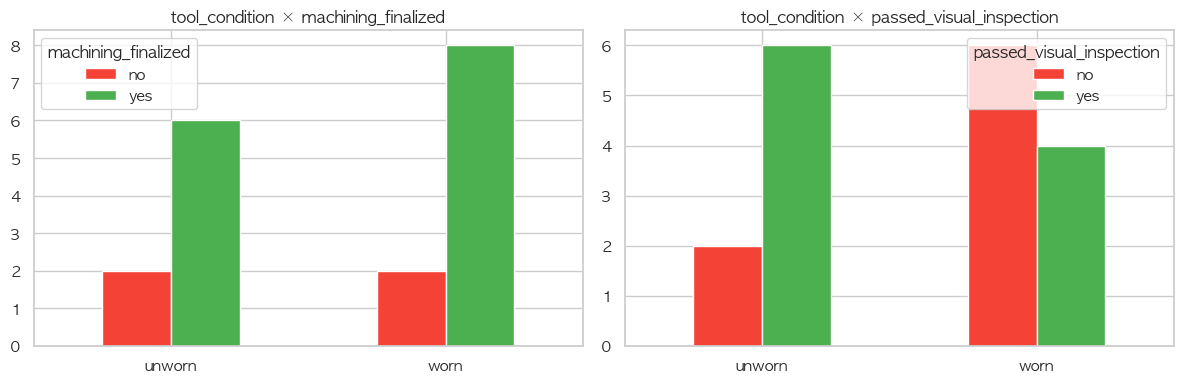

In [8]:
# --- 출력 라벨 교차표: 공구 상태 × 가공완료 / 육안검사 (실험 18건) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, L in zip(ax, ["machining_finalized", "passed_visual_inspection"]):
    pd.crosstab(exp_meta["tool_condition"], exp_meta[L]).plot(
        kind="bar", ax=a, color=["#F44336", "#4CAF50"])
    a.set_title(f"tool_condition × {L}"); a.set_xlabel(""); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**[인사이트]** 출력 라벨을 비교하면 도메인 통찰이 보입니다.
- '육안검사 불합격'이 '가공 미완료'보다 많습니다 → 기계 가공이 그 자체로 완벽하진 않으며, **기계는 못 잡지만
  사람이 잡아내는 결함**이 존재합니다.
- '가공 미완료'는 worn/unworn 차이가 작지만, **'육안검사 불합격'은 worn 쪽이 더 많습니다** → 닳은 공구가
  가공을 멈추진 않아도, 사람이 알아챌 **미세한 품질 저하**를 만든다는 해석.

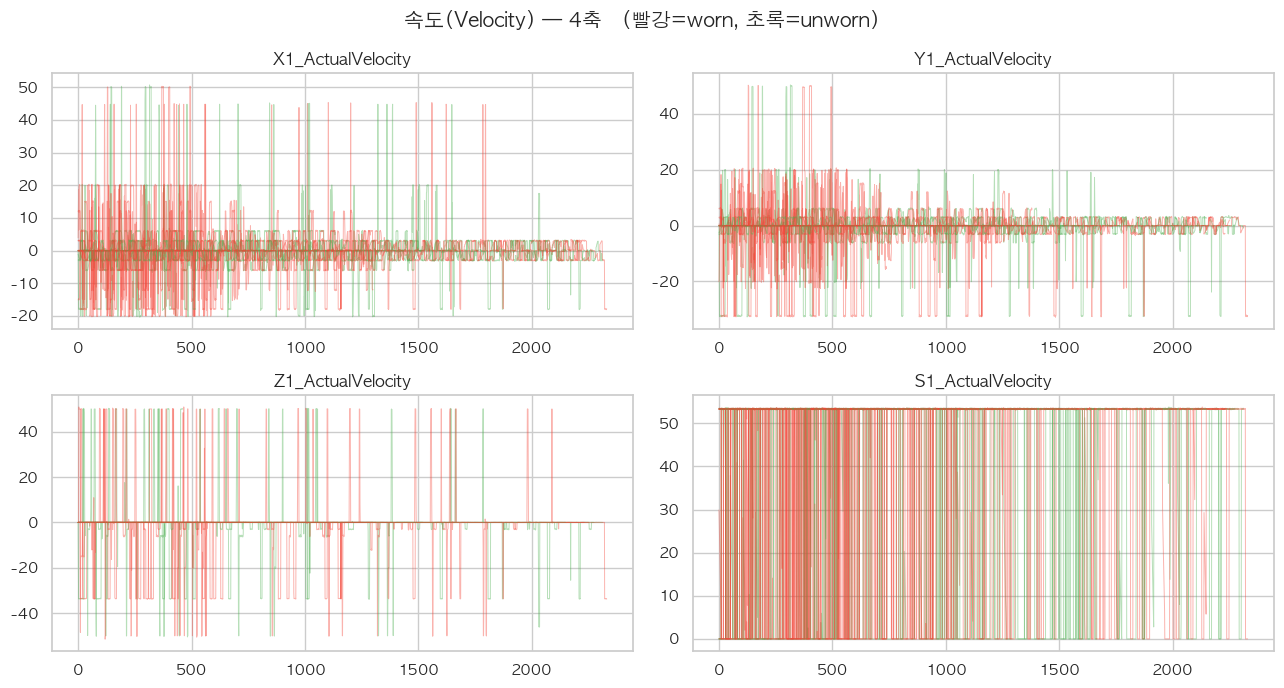

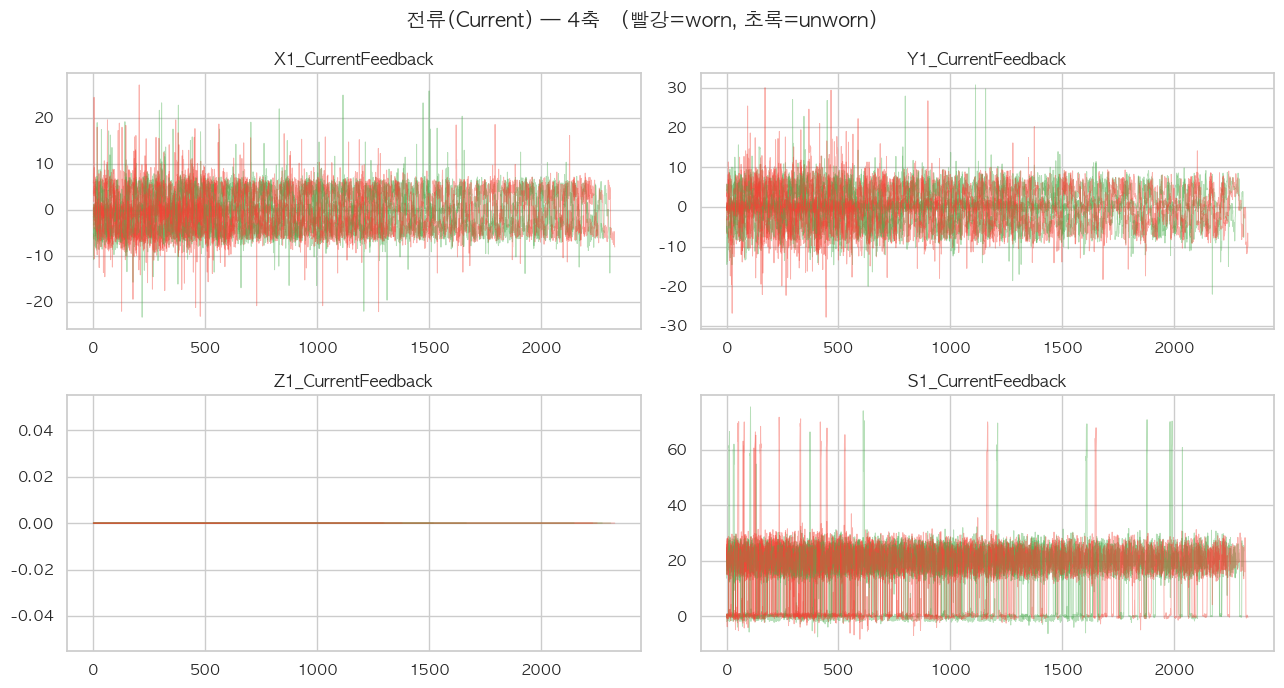

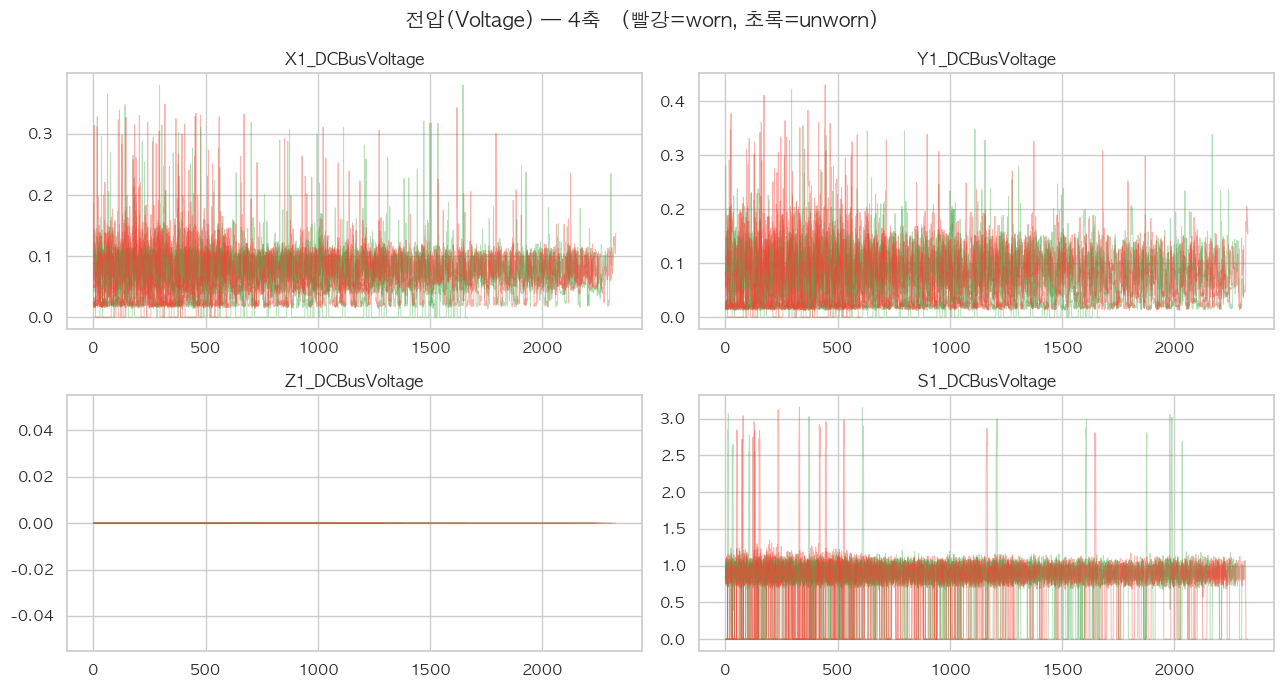

In [9]:
# --- 18개 실험 시계열 겹쳐보기 (빨강=worn / 초록=unworn) : 속도·전류·전압 4축 ---
def plot_ts_grid(cols, title):
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    for a, col in zip(axes.ravel(), cols):
        for n in range(1, 19):
            g = df[df["exp_num"] == n]
            cond = exp_meta[exp_meta["No"] == n]["tool_condition"].iloc[0]
            a.plot(np.arange(len(g)), g[col].values,
                   color=("#F44336" if cond == "worn" else "#4CAF50"), alpha=0.4, linewidth=0.7)
        a.set_title(col)
    plt.suptitle(title + "   (빨강=worn, 초록=unworn)"); plt.tight_layout(); plt.show()

plot_ts_grid(["X1_ActualVelocity","Y1_ActualVelocity","Z1_ActualVelocity","S1_ActualVelocity"], "속도(Velocity) — 4축")
plot_ts_grid(["X1_CurrentFeedback","Y1_CurrentFeedback","Z1_CurrentFeedback","S1_CurrentFeedback"], "전류(Current) — 4축")
plot_ts_grid(["X1_DCBusVoltage","Y1_DCBusVoltage","Z1_DCBusVoltage","S1_DCBusVoltage"], "전압(Voltage) — 4축")

**[해석법]** 한 선이 실험 하나의 시간에 따른 신호입니다. 18개를 겹쳐 worn은 빨강, unworn은 초록으로 칠했어요.
색이 위아래로 깔끔히 갈리면 그 신호로 마모를 구분할 수 있다는 뜻인데 — **빨강·초록이 뒤섞여 있습니다.**
→ **원시 신호만으로는 worn/unworn이 잘 구분되지 않습니다.** 4절에서 의미 있는 특징으로 바꿉니다.

In [10]:
# --- 축별 정보량 점검: 어느 축이 신호를 담고 있나 (전처리/피처 선택의 근거) ---
axis_var = {}
for ax in ["X1","Y1","Z1","S1"]:
    axis_var[ax] = cut[f"{ax}_OutputCurrent"].std()
print("축별 OutputCurrent 표준편차(변동성):")
for k,v in axis_var.items():
    print(f"  {k}: {v:.3f}" + ("   ← 거의 0 = 정보 없음(제외 후보)" if v < 0.01 else ""))

축별 OutputCurrent 표준편차(변동성):
  X1: 1.483
  Y1: 1.803
  Z1: 0.000   ← 거의 0 = 정보 없음(제외 후보)
  S1: 4.279


**[피처 선택 인사이트]** **Z축은 변동이 거의 0입니다.** 이 가공에서 Z축(깊이 방향)은 거의 안 움직여서
**정보를 담고 있지 않습니다.** → 특징을 만들 때 Z축은 빼도 됩니다. *"모든 컬럼을 다 쓰지 말고, 정보가 있는
축만 골라 쓴다"* 가 피처 선택의 출발점입니다. (반대로 X·S축은 절삭 부하가 커서 마모 신호가 잘 실립니다.)

In [11]:
# --- 도메인 특징 미리보기: 추종 오차(|Command - Actual|)는 마모를 가를까? ---
for ax in ["X1","S1"]:
    cut[f"{ax}_VelErr"] = (cut[f"{ax}_CommandVelocity"] - cut[f"{ax}_ActualVelocity"]).abs()
comp = cut.groupby("target")[["X1_VelErr","S1_VelErr"]].mean()
comp.index = ["unworn","worn"]
print("속도 추종오차 평균 (worn vs unworn):")
print(comp.round(3))
print("\n→ worn에서 추종오차가 더 큰가? (마모되면 지령을 못 따라간다는 물리 직관)")

속도 추종오차 평균 (worn vs unworn):
        X1_VelErr  S1_VelErr
unworn      0.139      0.337
worn        0.177      0.449

→ worn에서 추종오차가 더 큰가? (마모되면 지령을 못 따라간다는 물리 직관)


**[도메인 인사이트]** 닳은 공구는 절삭 저항이 커져 **지령(Command)대로 움직이기 어려워집니다.**
실제로 속도 추종오차(|Command−Actual|)가 worn에서 더 큽니다. → 원시 신호 대신 **이 '추종오차'를 특징으로
만들면** 마모 신호가 더 잘 드러날 수 있습니다(4절에서 특징으로 추가). *EDA에서 얻은 직관이 곧 특징공학의 설계도가 됩니다.*

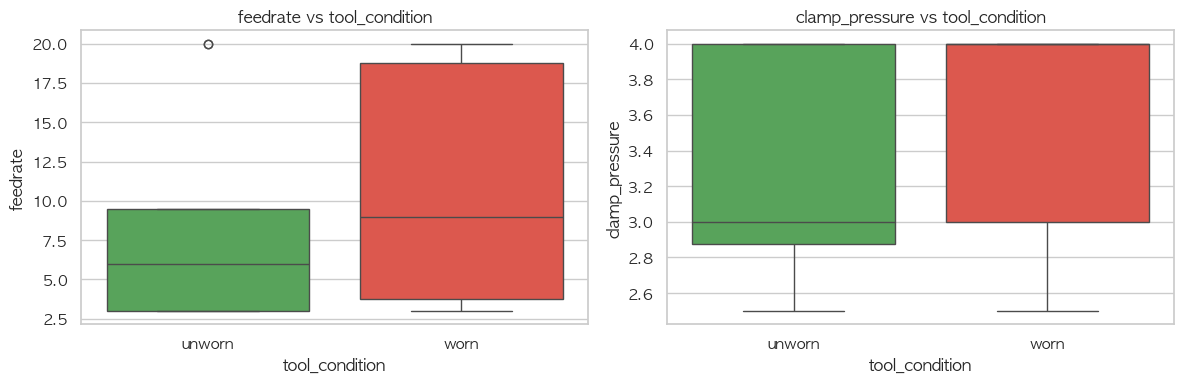

In [12]:
# --- feedrate / clamp_pressure 와 공구 상태 (실험 18건) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=exp_meta, x="tool_condition", y="feedrate", order=["unworn","worn"],
            palette=["#4CAF50","#F44336"], ax=ax[0]); ax[0].set_title("feedrate vs tool_condition")
sns.boxplot(data=exp_meta, x="tool_condition", y="clamp_pressure", order=["unworn","worn"],
            palette=["#4CAF50","#F44336"], ax=ax[1]); ax[1].set_title("clamp_pressure vs tool_condition")
plt.tight_layout(); plt.show()

**[관찰]** clamp_pressure는 worn/unworn이 거의 같지만, **feedrate는 worn 쪽 분포가 더 넓습니다.**

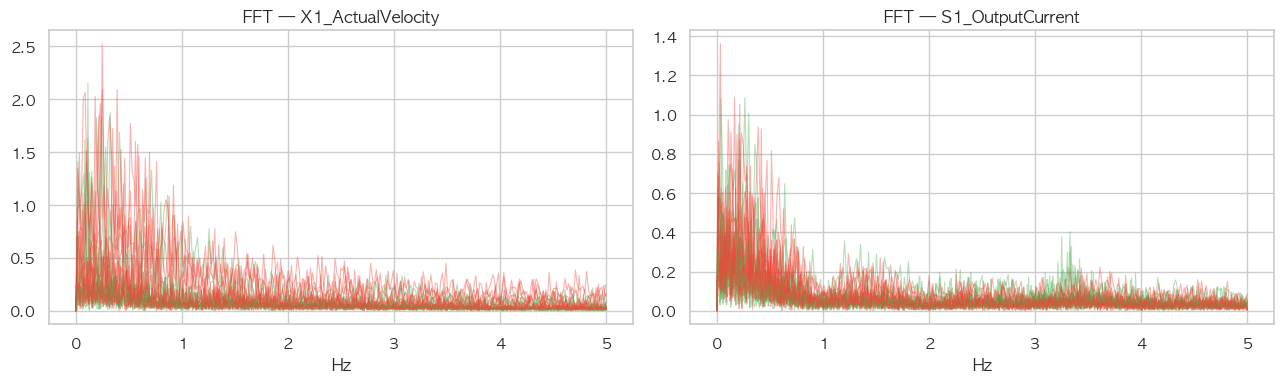

In [13]:
# --- 주파수 분석(FFT): 18개 실험 겹쳐보기 ---
def plot_fft(col, ax):
    dt = 0.1
    for n in range(1, 19):
        s = df[df["exp_num"] == n][col].values; s = s - s.mean()
        if len(s) < 4: continue
        f = np.fft.rfftfreq(len(s), d=dt); amp = np.abs(np.fft.rfft(s)) / len(s)
        cond = exp_meta[exp_meta["No"] == n]["tool_condition"].iloc[0]
        ax.plot(f, amp, color=("#F44336" if cond=="worn" else "#4CAF50"), alpha=0.4, linewidth=0.8)
    ax.set_title(f"FFT — {col}"); ax.set_xlabel("Hz")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_fft("X1_ActualVelocity", axes[0]); plot_fft("S1_OutputCurrent", axes[1])
plt.tight_layout(); plt.show()

**[해석법]** 가로축은 주파수(Hz), 세로축은 그 성분의 세기(진폭)입니다. 봉우리(peak)가 신호의 주된 박자예요.

> **FFT 해석 주의** — 10Hz 샘플링이라 5Hz까지만 봅니다(나이퀴스트). 여기 저주파는 '가공 단계의 큰 흐름'이지
> 공구 떨림 같은 진동 시그니처가 아닙니다. (진짜 진동·채터링은 6절 합성 신호 실습에서 다룹니다.)

### EDA 요약 — 전처리·특징공학 설계도
이 EDA에서 얻은 인사이트가 다음 단계(특징공학)의 근거가 됩니다.
| EDA 발견 | 전처리·특징 설계로 연결 |
|---|---|
| 비절삭 구간 30% | 절삭 구간만 사용(이미 적용) |
| 원시 신호로는 worn/unworn 안 갈림 | 윈도우 요약 특징 필요 |
| Z축 변동 ≈ 0 | Z축은 특징에서 제외 |
| X·S축에 절삭 부하 집중 | X·S축 신호 위주로 특징 구성 |
| worn에서 속도 추종오차 큼 | 추종오차(Command−Actual)를 특징으로 추가 |

---
## 4. 특징공학 — EDA 인사이트를 특징으로  ` [1-1 알고리즘]` ⭐ 이 세션의 핵심

### 왜 특징공학이 핵심인가
EDA에서 봤듯 **원시 신호(0.1초마다 찍힌 값)는 그대로 쓰면 worn/unworn이 안 갈립니다.** 또 한 점만 보면
정보가 빈약하고, 25,286행을 통째로 넣으면 차원의 저주에 걸립니다. 그래서 *"신호 구간의 성질을 요약한
의미 있는 숫자"* 로 바꿔줘야 합니다. 이것이 **특징공학(feature engineering)** 이고, 모델 성능을 좌우하는 가장 중요한 단계입니다.

### 3가지 설계 결정 (모두 EDA 인사이트에서 나옴)
1. **어떤 축을?** → EDA에서 Z축은 변동≈0(정보 없음)이라 빼고, 정보가 있는 X·Y·S축 위주로.
2. **어떻게 묶나?** → 1초(10스텝) **슬라이딩 윈도우**로 묶어 구간 통계를 낸다(한 점은 정보 부족).
3. **무슨 값을?** → 아래 시간·주파수·도메인 특징.

### 윈도우마다 뽑는 특징
**(A) 시간 도메인** — 신호의 모양·세기
- **RMS** = √(평균(x²)) : 신호가 평균적으로 얼마나 센가(에너지). 절삭 부하↑ → RMS↑
- **Kurtosis(첨도)** : 뾰족한 충격이 얼마나 튀나. 미세 균열·마모 시 상승

**(B) 주파수 도메인** — 신호가 얼마나 빨리 떨리나
- **Wavelet Energy** = ∑|cD|² : DWT(db4)의 고주파 세부계수 에너지. FFT는 '언제'를 모르지만
  웨이블릿은 시간·주파수를 동시에 본다. 신호를 큰 흐름(cA)+잔떨림(cD)으로 나눠 cD의 에너지를 쓴다.
  (정직하게: 10Hz라 'kHz 진동'이 아니라 0~5Hz 안의 빠른 변동 정도)

**(C) 도메인 지식 특징** — 물리를 아는 사람만 만들 수 있는 특징
- **추종 오차** = |Command − Actual| : EDA에서 worn일 때 속도 추종오차가 더 컸다. 닳은 공구는 지령을
  못 따라간다는 물리를 특징으로 직접 인코딩한다. (단순 통계가 못 잡는 신호)

In [14]:
# --- 도메인 특징(추종 오차)을 먼저 만들어 둔다: |Command - Actual| ---
for ax in ["X1", "Y1", "S1"]:   # Z축은 정보가 없어 제외 (EDA 인사이트)
    cut[f"{ax}_VelErr"] = (cut[f"{ax}_CommandVelocity"] - cut[f"{ax}_ActualVelocity"]).abs()

# 특징을 뽑을 센서/신호 목록 (Z축 OutputCurrent 제외 = 정보 없음)
SENSORS = ["X1_OutputCurrent", "Y1_OutputCurrent", "S1_OutputCurrent",
           "S1_OutputPower", "X1_ActualVelocity", "S1_ActualVelocity",
           "X1_VelErr", "S1_VelErr"]   # ← 마지막 2개가 도메인 특징(추종오차)
print("특징 추출 대상 신호:", SENSORS)

특징 추출 대상 신호: ['X1_OutputCurrent', 'Y1_OutputCurrent', 'S1_OutputCurrent', 'S1_OutputPower', 'X1_ActualVelocity', 'S1_ActualVelocity', 'X1_VelErr', 'S1_VelErr']


In [15]:
# --- 슬라이딩 윈도우 특징 추출: 신호마다 RMS·Kurtosis·Wavelet 에너지 ---
W = 10   # 10스텝 = 1초
def window_features(arr):
    rms = np.sqrt(np.mean(arr**2)); m, s = arr.mean(), arr.std()
    kurt = np.mean(((arr - m) / s)**4) if s > 0 else 0.0      # 첨도
    _, cD = pywt.dwt(arr, "db4"); we = np.sum(cD**2)          # Wavelet 에너지
    return rms, kurt, we

rows = []
for e, g in cut.groupby("exp_num"):           # ⭐ 실험 안에서만 윈도우 → 경계 안 넘음
    g = g.reset_index(drop=True); label = int(g["target"].iloc[0])
    for st in range(0, len(g) - W + 1, W):    # 겹침 없는(non-overlapping) 윈도우
        w = g.iloc[st:st+W]; fd = {"exp_num": e, "target": label}
        for c in SENSORS:
            r, k, we = window_features(w[c].values)
            fd[f"{c}_RMS"], fd[f"{c}_Kurt"], fd[f"{c}_WE"] = r, k, we
        rows.append(fd)
fe = pd.DataFrame(rows)
print(f"윈도우 샘플 {fe.shape[0]}개, 특징 {fe.shape[1]-2}개 ({len(SENSORS)}신호 × 3특징)")
fe.head(3)

윈도우 샘플 1743개, 특징 24개 (8신호 × 3특징)


,exp_num,target,X1_OutputCurrent_RMS,X1_OutputCurrent_Kurt,X1_OutputCurrent_WE,Y1_OutputCurrent_RMS,Y1_OutputCurrent_Kurt,Y1_OutputCurrent_WE,S1_OutputCurrent_RMS,S1_OutputCurrent_Kurt,...,X1_ActualVelocity_WE,S1_ActualVelocity_RMS,S1_ActualVelocity_Kurt,S1_ActualVelocity_WE,X1_VelErr_RMS,X1_VelErr_Kurt,X1_VelErr_WE,S1_VelErr_RMS,S1_VelErr_Kurt,S1_VelErr_WE
0,1,0,325.103214,2.917905,4.239668e+00,324.202097,2.666090,2.246314,317.444798,3.006575,...,9.153206,46.275739,2.835213,1.282907,0.116598,2.415556,0.007584,0.477493,1.202708,0.009369
1,1,0,326.000000,0.000000,2.821320e-27,324.500385,1.000000,2.053695,320.501326,2.162630,...,0.108273,53.280053,1.846939,0.043830,0.103150,1.655545,0.035598,0.077460,1.166667,0.016530
2,1,0,326.000000,0.000000,2.821320e-27,324.600370,1.166667,2.042298,320.700639,2.294468,...,16.607195,53.280053,4.142857,0.020264,0.180607,2.144761,0.043650,0.077460,3.611570,0.010892


**[코드 설명]**
- `groupby("exp_num")` 안에서만 윈도우를 잘라 **실험 경계를 절대 넘지 않게** 했습니다(5절 올바른 분할의 토대).
- 겹침 없는 윈도우를 쓴 이유: 겹치면 인접 윈도우가 비슷해져 **윈도우 간 독립성**이 깨집니다(누수 위험).
- Z축을 뺀 이유: EDA에서 변동≈0이라 정보가 없어서. **정보 없는 컬럼을 넣으면 잡음만 늘립니다.**

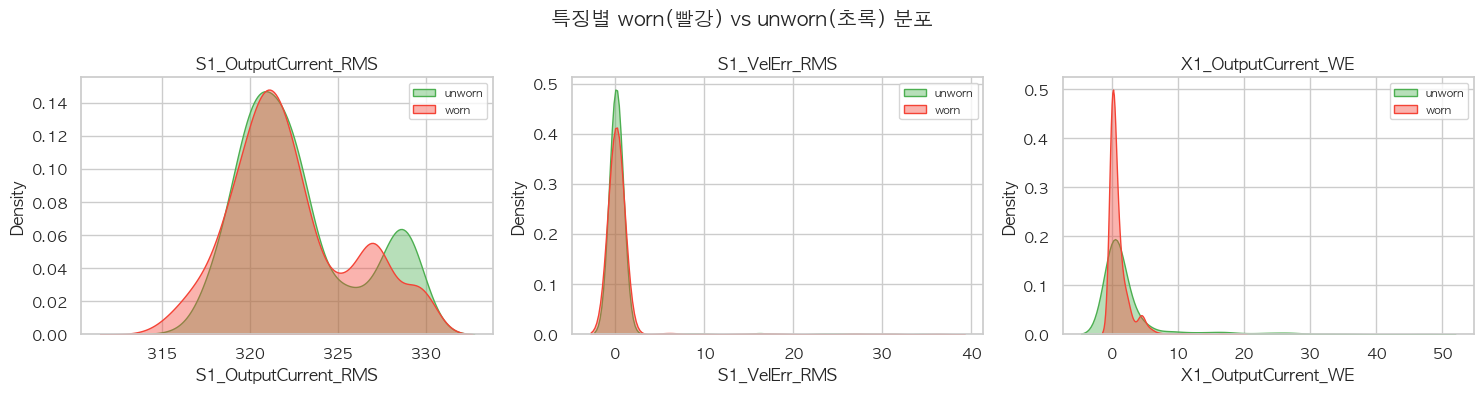

In [16]:
# --- 만든 특징이 worn/unworn을 가르는지 확인 (특징공학 검증) ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, feat in zip(ax, ["S1_OutputCurrent_RMS", "S1_VelErr_RMS", "X1_OutputCurrent_WE"]):
    for t, c in [(0, "#4CAF50"), (1, "#F44336")]:
        sns.kdeplot(fe[fe["target"]==t][feat], ax=a, color=c, fill=True, alpha=0.4,
                    label=("worn" if t else "unworn"))
    a.set_title(feat); a.legend(fontsize=8)
plt.suptitle("특징별 worn(빨강) vs unworn(초록) 분포"); plt.tight_layout(); plt.show()

**[해석]** 원시 신호(EDA)에선 안 갈렸지만, **요약 특징으로 바꾸니 분포가 조금씩 갈리기 시작**합니다(완전히는 아님).
이것이 특징공학의 효과입니다. 다만 5절에서 보겠지만, 18개 실험이라는 한계 때문에 **이 정도로는 충분치 않습니다.**

---
## 5. 올바른 분할과 모델링  ` [1-1, 1-3]`

> 이 세션의 초점은 **전처리·특징공학(2~4절)** 입니다. 모델링은 *"우리가 만든 특징이 쓸 만한지 정직하게 채점"* 하는
> 단계로만 가볍게 다룹니다. 즉 여기서 중요한 건 "어떤 모델을 쓰느냐"가 아니라 **"어떻게 평가하느냐"** 입니다.

### 왜 '실험 단위'로 나눠야 하나 (데이터 누수 방지)
모델 성능은 **학습용(train)** 과 **시험용(test, 한 번도 안 본 데이터)** 으로 나눠 평가합니다.
그런데 이 데이터는 **함정**이 있습니다.

같은 실험의 인접 윈도우는 거의 똑같이 생겼습니다. 만약 행을 **무작위로 섞어** 나누면, 실험 7번의 조각이
학습용과 시험용 양쪽에 들어가서, 모델이 *"마모란 무엇인가"* 가 아니라 *"이건 몇 번 실험이지?"* 를 외워버립니다.
시험 문제를 미리 본 셈이라 정확도가 비현실적으로 높아져요 — 이것이 **데이터 누수(Data Leakage)** 입니다.

> **그래서 이 노트북은 처음부터 `GroupKFold`(실험 단위 분할)만 씁니다.** 같은 실험은 학습·시험 중
> **오직 한쪽에만** 들어가, 모델은 *완전히 새로운 실험* 에서 얼마나 맞히는지로만 평가됩니다(=현장 성능).

### 알고리즘
- **LightGBM (그래디언트 부스팅)**: 트리를 순서대로 더하며 앞 트리의 오차를 보완. 표 데이터의 표준 강자.
  - 표 데이터에 강하고, 스케일 정규화가 필요 없으며(트리는 임계치로 분기), 비선형·상호작용·상관 변수에 강건,
    특징 중요도를 공짜로 줍니다. (RandomForest·XGBoost도 합리적 선택이며 LightGBM은 가볍고 빠른 기본값.)
- **SMOTE**: 소수 클래스를 보간해 합성. **단, 각 폴드의 학습 부분에만** 적용(파이프라인이 보장 → 누수 방지).
- **평가지표**: 정확도 대신 **Precision/Recall/F1**. 특히 닳은 공구(worn)를 놓치지 않는 **Recall**이 중요.

In [17]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import lightgbm as lgb

X = fe.drop(columns=["exp_num","target"]); y = fe["target"].values; groups = fe["exp_num"].values
baseline = max(y.mean(), 1 - y.mean())   # 다수 클래스만 찍는 기준선

def make_pipe():
    return Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                                random_state=RANDOM_STATE, verbose=-1))])

# GroupKFold(5): 같은 실험은 한 폴드에만 → 모든 윈도우가 정확히 한 번 '새 실험'으로 평가됨
oof = np.zeros(len(y), dtype=int); fold_acc = []
for tr, te in GroupKFold(5).split(X, y, groups):
    oof[te] = make_pipe().fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
    fold_acc.append(accuracy_score(y[te], oof[te]))

print(f"GroupKFold(5) 폴드별 정확도: {[round(a,2) for a in fold_acc]}")
print(f"평균 정확도: {np.mean(fold_acc):.3f} ± {np.std(fold_acc):.3f}")
print(f"다수 클래스 기준선: {baseline:.3f}")

GroupKFold(5) 폴드별 정확도: [0.65, 0.68, 0.32, 0.64, 0.32]
평균 정확도: 0.521 ± 0.166
다수 클래스 기준선: 0.541


              precision    recall  f1-score   support

      unworn       0.48      0.41      0.44       800
        worn       0.55      0.61      0.58       943

    accuracy                           0.52      1743
   macro avg       0.51      0.51      0.51      1743
weighted avg       0.52      0.52      0.52      1743



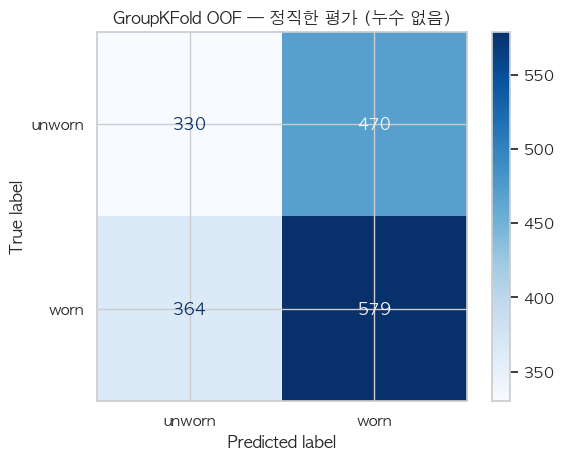

In [18]:
# --- 정직한 성능 리포트 ---
print(classification_report(y, oof, target_names=["unworn","worn"]))
ConfusionMatrixDisplay(confusion_matrix(y, oof), display_labels=["unworn","worn"]).plot(cmap="Blues")
plt.title("GroupKFold OOF — 정직한 평가 (누수 없음)"); plt.show()

**[해석]** 누수 없이 정직하게 평가하니 정확도가 **기준선 근처**입니다. 게다가 폴드마다 출렁이죠.
실망스러워 보이지만 **이게 진짜 실력**이고, 중요한 통찰로 이어집니다.

### 핵심 통찰: 유효 표본은 윈도우 수가 아니라 **실험 18개**
라벨(worn/unworn)은 **실험 단위**로 붙습니다. 그래서 한 실험의 수백 윈도우는 독립 표본이 아니라
**같은 라벨의 복제**예요. → **유효 표본 ≈ 18개** (전형적 p≫n). 윈도우를 더 잘게 잘라도 정보량은 안 늘어납니다.

> 즉 성능이 낮은 건 **버그가 아니라 데이터 부족(Data Scarcity)** 입니다. 이것이 이후 세션
> (딥러닝·**생성형 AI로 합성 데이터 만들기**)이 필요한 이유로 직접 연결됩니다.

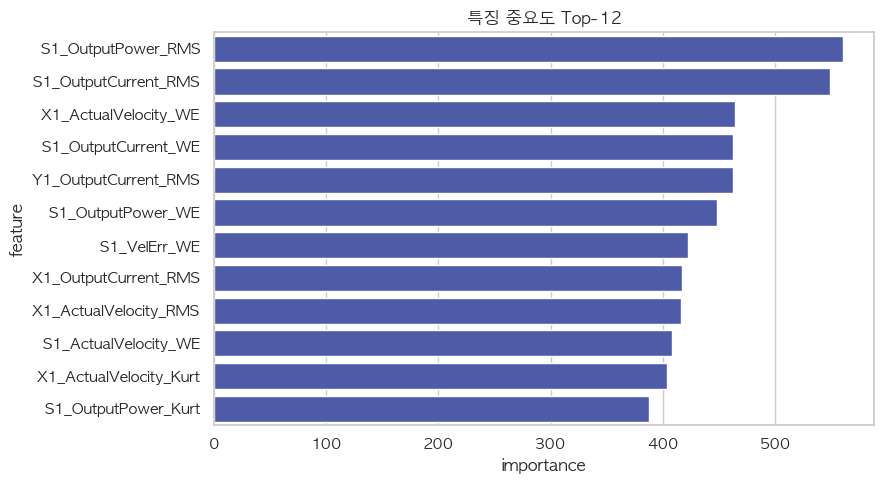

In [19]:
# --- 특징 중요도: 어느 축·신호가 (그나마) 마모를 가르는가 ---
imp_model = lgb.LGBMClassifier(n_estimators=300, class_weight="balanced",
                               random_state=RANDOM_STATE, verbose=-1).fit(X, y)
imp = pd.DataFrame({"feature": X.columns, "importance": imp_model.feature_importances_}).sort_values("importance", ascending=False).head(12)
plt.figure(figsize=(9,5)); sns.barplot(data=imp, y="feature", x="importance", color="#3F51B5")
plt.title("특징 중요도 Top-12"); plt.tight_layout(); plt.show()

**[해석 — 피처 관점]** 특징 중요도는 *"우리가 만든 특징 중 무엇이 쓸모 있었나"* 를 알려줍니다.
- 보통 **S(주축)·X축**의 전류/전력 RMS·Wavelet 에너지, 그리고 **추종오차(VelErr)** 특징이 상위에 옵니다 —
  EDA에서 예측한 그대로(절삭 부하가 큰 축 + 마모 시 추종 악화). **EDA 인사이트 → 특징 설계 → 중요도 검증**의 한 바퀴가 닫힙니다.
- **Z축 특징은 애초에 안 만들었습니다**(EDA에서 정보≈0). 불필요한 특징을 빼는 것도 피처 엔지니어링입니다.

> 단, 유효표본 18개라 중요도가 곧 높은 예측력을 뜻하진 않습니다. '모델이 무엇을 보는가'의 해석 도구로만 보세요.

---
## 6. Claude Code 실습 — 직접 AI에게 시켜보기

지금까지는 완성된 코드를 따라왔습니다. 이제 **여러분이 직접 Claude Code(또는 Claude)에게 프롬프트를 던져**
코드를 만들고, 결과를 **해석·검증**해 봅니다. *"무엇을 시킬지(요구사항)를 명확히 적는 것"* 이 핵심 역량입니다.

### 실습 B. 특징을 추가하면 성능이 좋아질까? — **메인 실습**

가장 흔한 직관: *"특징을 더 많이 넣으면 모델이 더 똑똑해지겠지."* 정말 그럴까요?
이 윈도우 특징 추출에 **두 가지 특징을 추가**하고, **5절과 똑같은 GroupKFold**로 성능을 비교해 봅니다.
- **Zero-Crossing Rate(ZCR)**: 신호가 평균선을 가로지르는 빈도 → "얼마나 자주 출렁이나"(주파수 감각)
- **Crest Factor**: peak / RMS → "평소 대비 순간 최댓값이 얼마나 튀나"(충격성)

> **Claude에게 던질 프롬프트 (그대로 복사해서 사용)**
> ```
> 이 윈도우 특징 추출 함수에 두 가지 특징을 추가해줘:
> - zero-crossing rate (신호가 평균선을 가로지르는 비율)
> - crest factor (최댓값 절댓값 / RMS)
> 그리고 '기존 3특징'과 '추가한 5특징'의 GroupKFold(5) 평균 정확도를 비교 출력해줘.
> 평가 방식(실험 단위 분할)은 절대 바꾸지 말 것.
> ```

아래는 **모범 답안 예시**입니다. 직접 만든 코드와 비교하세요.

In [20]:
# === 실습 B 모범답안: 특징 추가 전/후 GroupKFold 비교 ===
def make_features(arr, extended=False):
    rms = np.sqrt(np.mean(arr**2)); m, s = arr.mean(), arr.std()
    kurt = np.mean(((arr - m) / s)**4) if s > 0 else 0.0
    _, cD = pywt.dwt(arr, "db4"); we = np.sum(cD**2)
    feats = [rms, kurt, we]                       # 기본 3특징
    if extended:
        zcr = np.mean(np.abs(np.diff(np.sign(arr - arr.mean())))) / 2   # zero-crossing rate
        crest = (np.max(np.abs(arr)) / rms) if rms > 0 else 0.0          # crest factor
        feats += [zcr, crest]                     # +2특징 → 총 5특징
    return feats

def build_feature_table(extended):
    rows = []
    for e, g in cut.groupby("exp_num"):
        g = g.reset_index(drop=True); label = int(g["target"].iloc[0])
        for st in range(0, len(g) - W + 1, W):
            w = g.iloc[st:st+W]; rec = {"exp_num": e, "target": label}
            for c in SENSORS:
                for j, v in enumerate(make_features(w[c].values, extended)):
                    rec[f"{c}_{j}"] = v
            rows.append(rec)
    return pd.DataFrame(rows)

def groupkfold_acc(tbl):
    Xx = tbl.drop(columns=["exp_num","target"]); yy = tbl["target"].values; gg = tbl["exp_num"].values
    accs = [accuracy_score(yy[te], make_pipe().fit(Xx.iloc[tr], yy[tr]).predict(Xx.iloc[te]))
            for tr, te in GroupKFold(5).split(Xx, yy, gg)]
    return np.mean(accs), np.std(accs), Xx.shape[1]

for name, ext in [("기본 (3특징/센서)", False), ("확장 (5특징/센서: +ZCR+Crest)", True)]:
    m, sd, ncol = groupkfold_acc(build_feature_table(ext))
    print(f"{name:30s} 특징 {ncol:2d}개 → GroupKFold 평균 {m:.3f} ± {sd:.3f}")

기본 (3특징/센서)                    특징 24개 → GroupKFold 평균 0.521 ± 0.166


확장 (5특징/센서: +ZCR+Crest)        특징 40개 → GroupKFold 평균 0.505 ± 0.170


**[해석 — 핵심 학습 포인트]** 특징을 늘려도 성능이 **오르지 않고 오히려 살짝 내려갑니다.** 왜일까요?
- **유효 표본이 18개**이기 때문입니다. 표본(정보)이 18개뿐인데 특징(차원)만 늘리면, 모델이 신호가 아니라
  **잡음에 과적합**하기 쉬워집니다(전형적 p≫n). "특징을 더 넣으면 좋아진다"는 직관이 깨지는 순간입니다.
- 교훈: **데이터가 부족할 땐 특징공학·모델 튜닝으로 한계를 넘기 어렵다.** 근본 해법은 *데이터를 늘리는 것*
  → 이후 세션의 **생성형 AI 합성 데이터**로 이어집니다.

> 직접 더 해보기(Claude에게): *"특징을 10개로 더 늘리면 정확도가 어떻게 되는지, 그리고 왜 그런지 설명해줘."*

### 실습 A. (보조) Wavelet로 채터링 노이즈 제거 — 합성 신호
진짜 진동 데이터(수 kHz)에는 **채터링(고주파 떨림)** 이 섞입니다. 우리 CNC 데이터는 10Hz라 채터링이 안 담기므로,
**진동 신호를 직접 합성해** Wavelet 노이즈 제거를 연습합니다(세션1 sec1과 연결).

> **Claude에게 던질 프롬프트**
> ```
> CNC 밀링머신 진동 데이터에서 채터링 노이즈를 제거하려고 해.
> pywt 라이브러리를 사용해서:
> - db4 wavelet으로 5레벨 분해
> - 상위 2개 레벨(고주파)에 soft threshold 적용
> - 재합성 후 원본과 결과를 subplot으로 비교
> 샘플 데이터는 numpy로 직접 생성해줘.
> ```

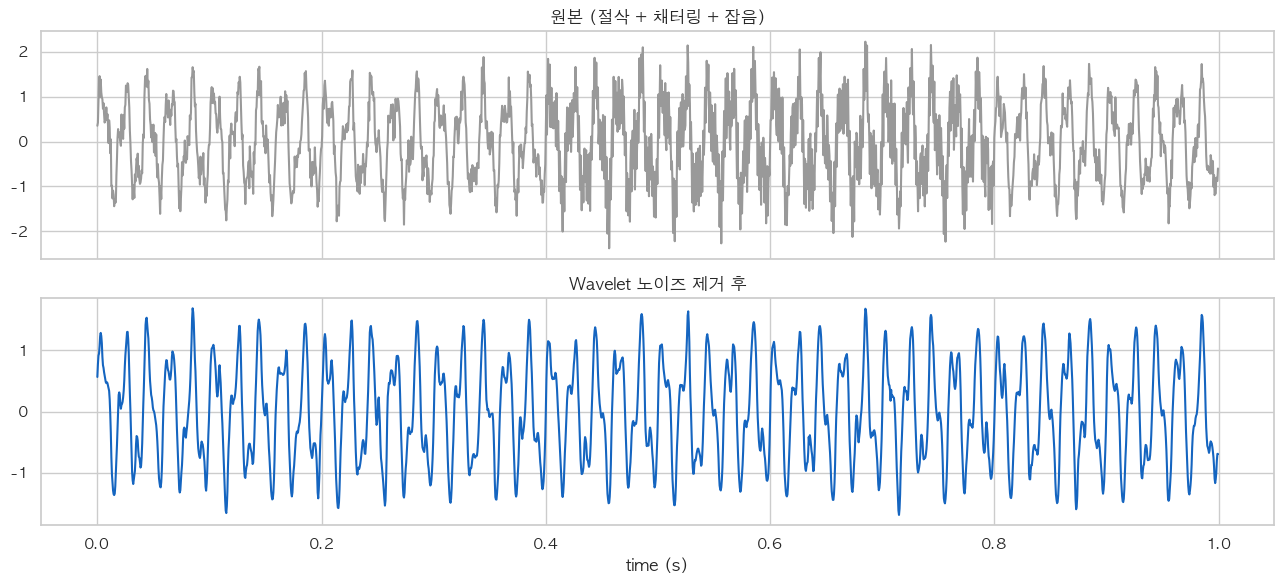

원본 표준편차 0.863 → 제거 후 0.801  (고주파 채터링·잡음 감소, 절삭 신호 보존)


In [21]:
# === 실습 A 모범답안: Wavelet 채터링 노이즈 제거 (합성 신호) ===
np.random.seed(0)
fs = 2000; t = np.linspace(0, 1, fs, endpoint=False)
cutting = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)        # 정상 절삭 신호(저주파)
chatter = 0.6*np.sin(2*np.pi*650*t) * ((t > 0.4) & (t < 0.8))     # 채터링(고주파, 0.4~0.8초)
white   = 0.2*np.random.randn(fs)                                 # 백색 잡음
sig = cutting + chatter + white

coeffs = pywt.wavedec(sig, "db4", level=5)        # [cA5, cD5, cD4, cD3, cD2, cD1]
def soft_thr(c):
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745          # cD1로 잡음 크기 추정(MAD)
    return pywt.threshold(c, sigma*np.sqrt(2*np.log(len(c))), mode="soft")
cf = coeffs.copy(); cf[-1] = soft_thr(coeffs[-1]); cf[-2] = soft_thr(coeffs[-2])   # 상위 2레벨
denoised = pywt.waverec(cf, "db4")[:len(sig)]

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t, sig, color="#999"); ax[0].set_title("원본 (절삭 + 채터링 + 잡음)")
ax[1].plot(t, denoised, color="#1565C0"); ax[1].set_title("Wavelet 노이즈 제거 후")
ax[1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()
print(f"원본 표준편차 {sig.std():.3f} → 제거 후 {denoised.std():.3f}  (고주파 채터링·잡음 감소, 절삭 신호 보존)")

**[직접 변형 — Claude에게]** *"db4 대신 sym5로, 레벨을 3으로 바꿔 비교"*, *"hard threshold로 바꿔보기"*,
*"채터링 주파수를 300Hz로"* → 무엇이 깎이고 무엇이 보존되는지 관찰하는 게 목적입니다.

### 실습 C. (도전) 평가 함정 스스로 찾기
> **프롬프트 예시**
> ```
> 이 데이터는 18개 실험의 시계열이고 라벨은 실험 단위로 붙어 있어.
> 행 단위 train_test_split(test_size=0.2)로 평가하면 정확도가 0.99가 나오는데,
> 왜 이게 잘못된 평가인지 설명하고, 올바른 코드로 고쳐줘.
> ```
체크포인트: Claude가 **데이터 누수**를 지적하고 `GroupKFold`를 제안하는지 확인 → 5절 개념을 AI로 재확인.

---
## 7. 정리

1. **전처리**: 절삭 구간만 사용(허공 이동 제외), 가공 후 판별값(machining_finalized 등)은 타깃 누수라 제외.
2. **특징공학**: 윈도우 단위 RMS·Kurtosis·Wavelet 에너지.
3. **올바른 평가**: 처음부터 **GroupKFold(실험 단위)** + 폴드 내 SMOTE. 정확도 말고 Precision/Recall/F1.
4. **유효 표본 18개**: 정직하게 보면 성능이 기준선 근처 — 버그가 아니라 **데이터 부족**.
5. **그래서 다음 세션**: 딥러닝·**생성형 AI 합성 데이터**로 표본 부족을 넘는다.
6. **Claude Code 실습**: 요구사항을 명확히 적어 AI에게 코드를 시키고, 결과를 **해석·검증**하는 역량.

> 메시지: "모델을 잘 돌리는 것"보다 **"정직하게 평가하는 것"**, 그리고 **"AI에게 정확히 시키고 결과를 비판적으로 읽는 것"** 이 핵심입니다.